# 확률적 경사 하강법
- 데이터의 크기가 매우 큰 경우
- 데이터가 한번에 수집되지 않은 경우
- 여러 번 반복을 통해서 점진적으로 결과값에 접근해야 할 경우
- 딥러닝에서 가장 많이 사용된다
- 중간에 거치는 함수가 많을 때, 최종 결과값에 계수가 미치는 영향을 
  계산하려면 천문학적인 연산량이 필요하다
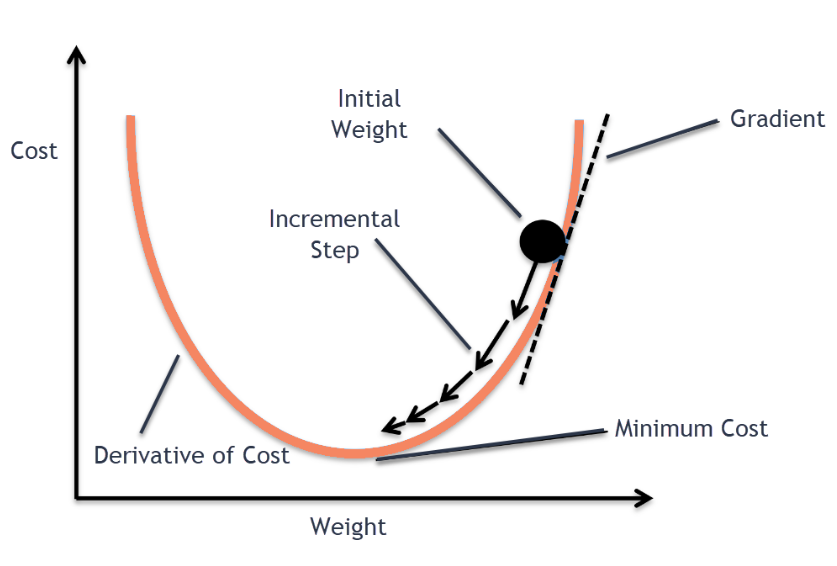

- Weight(기울기,계수)가 Cost에 미치는 영향을 계산하려면 미분을 해야 한다
- 그런데 Weight와 Cost사이에는 여러 단계의 함수를 거치므로 한번에 계산을
  할 수 없다
- 그래서 체인룰을 사용해서 계산한다
- 기울기의 +, -에 따라 Weight를 증가/감소 방향이 결정된다
- 이렇게 많은 데이터를 반복적으로 학습시켜 점진적으로 정답에 가깝도록
  유도하는 알고리즘을 ```경사 하강법``` 이라고 한다

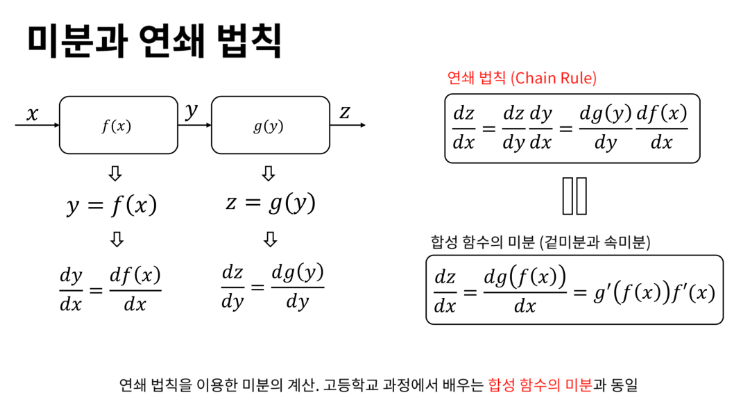

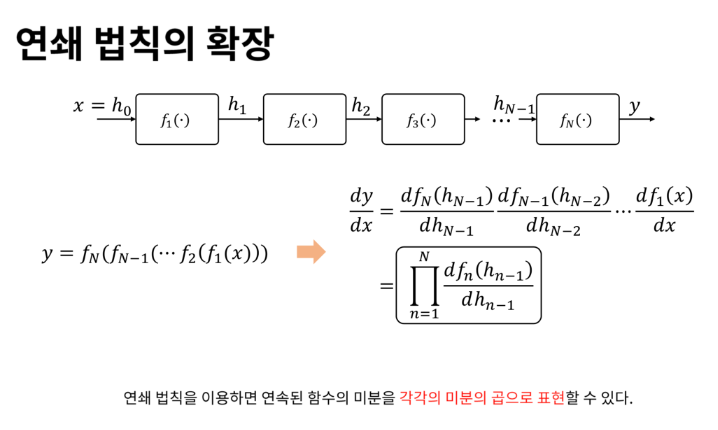

## 경사 하강법의 종류
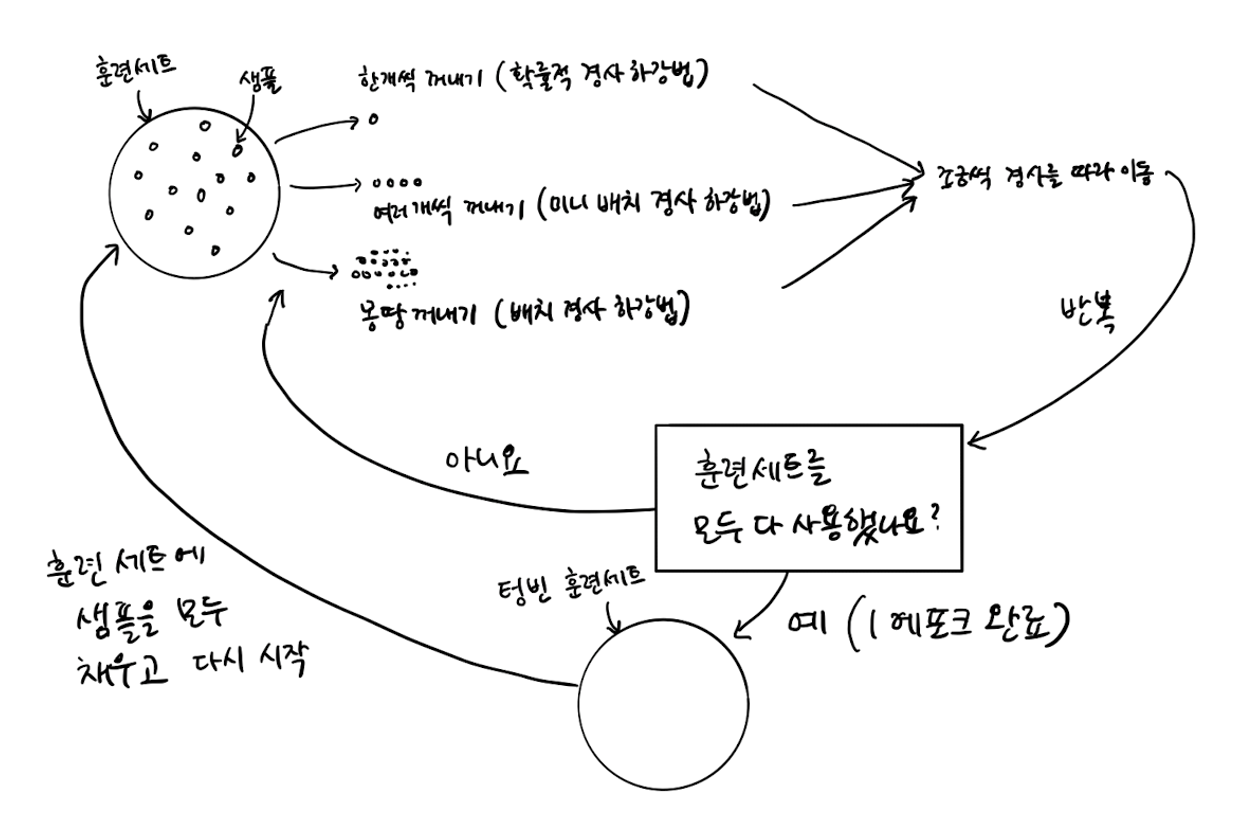

## Cost 비용, loss 손실
- 비용함수(손실함수) 원하는 결과와 얼마나 차이가 발생하는가를 계산
- 로지스틱 손실함수(Logistic loss function)
  = 이진 크로스엔트로피 손실함수(binary cross-entropy loss function)
  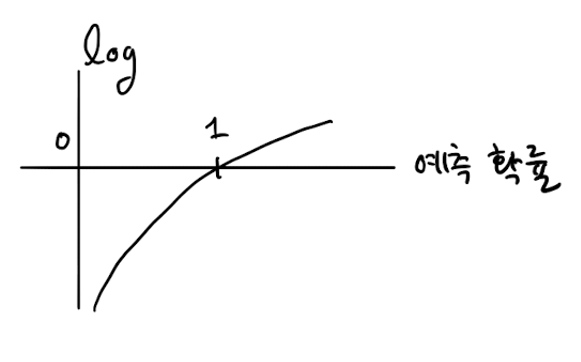


  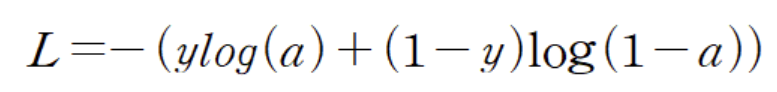

  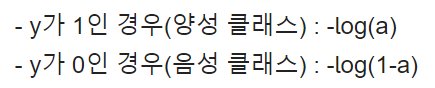
  - 결과가 0이냐 1이냐에 따라 함수를 2개 사용해야 하는데
    1개 함수로 통합해서 사용하려고 만들어진 수식

  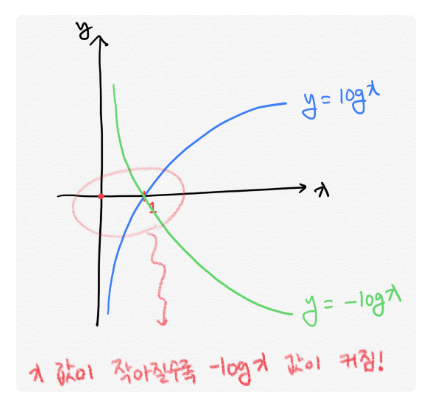

  - cost 값이 큰 양수면 정답 확률과 차이가 크고
    cost 값이 작은 양수면 정답 확률과 가깝다

In [1]:
import pandas as pd

fish = pd.read_csv('fish.csv')
fish

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [3]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [4]:
fish.tail()

,Species,Weight,Length,Diagonal,Height,Width
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672
158,Smelt,19.9,15.0,16.2,2.9322,1.8792


In [5]:
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    object 
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.6+ KB


In [6]:
fish.describe()

,Weight,Length,Diagonal,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,28.415723,31.227044,8.970994,4.417486
std,357.978317,10.716328,11.610246,4.286208,1.685804
min,0.000000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,63.400000,68.000000,18.957000,8.142000


In [8]:
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

print(fish_input.shape)
print(fish_target.shape)

(159, 5)
(159,)


In [9]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = \
    train_test_split(fish_input, fish_target, random_state=42)

print(train_input.shape)
print(test_input.shape)

(119, 5)
(40, 5)


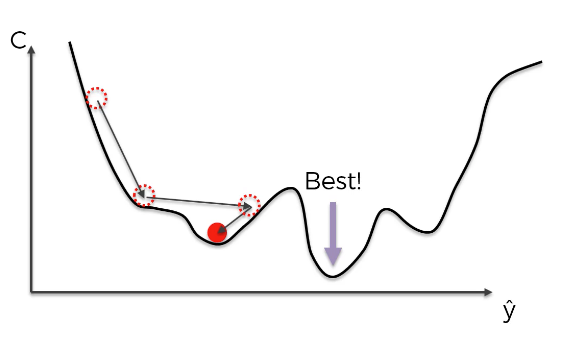

In [10]:
# 속성값들의 단위가 다르므로, 정규화를 통해 표준점수로 각 속성들을 전환
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

print(train_scaled[:5])

[[ 0.91965782  0.60943175  0.81041221  1.85194896  1.00075672]
 [ 0.30041219  1.54653445  1.45316551 -0.46981663  0.27291745]
 [-1.0858536  -1.68646987 -1.70848587 -1.70159849 -2.0044758 ]
 [-0.79734143 -0.60880176 -0.67486907 -0.82480589 -0.27631471]
 [-0.71289885 -0.73062511 -0.70092664 -0.0802298  -0.7033869 ]]


In [11]:
from sklearn.linear_model import SGDClassifier

# log : 로지스틱 손실 함수
# max_iter : 전체 epoch(전체 데이터 1번 학습) 횟수
sc = SGDClassifier(loss='log', max_iter=10, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.773109243697479
0.775


c:\ProgramData\anaconda3\envs\mldl\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:557: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)


## 위에서 학습을 이어서 추가학습할 때는 partial_fit를 사용
## 1 epoch 학습이 진행됨

In [12]:
sc.partial_fit(train_scaled, train_target)      
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.8151260504201681
0.825


## 하이퍼파라미터(hypterparameter)
- 실험을 통해서 최적의 파라미터를 찾아야 한다
- 다양한 값을 변경해가면서 찾는다
- 시각화가 도움이 된다

In [13]:
import numpy as np

sc = SGDClassifier(loss='log', random_state=42)
train_score = []
test_score = []
classes = np.unique(train_target)

# _는 변수의 자리에 아무 값도 받지 않겠다는 뜻
for _ in range(0, 300):
    sc.partial_fit(train_scaled, train_target, classes=classes)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

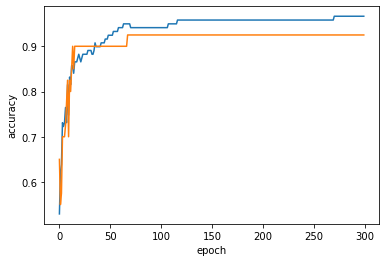

In [14]:
import matplotlib.pyplot as plt

plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

## 과대적합(Overfitting)이나 과소적합(Underfitting)은 모두 안 좋다
- 과대적합은 지나치게 훈련데이터에 최적화되게 되므로, 범용성이 떨어진다
- 과소적합은 아직 훈련이 덜 진행된 것이나 해당되는 데이터를 학습하기에 데이터 종류나 알고리즘이 단순함을 의미한다
- 위에서는 훈련데이터와 테스트데이터의 점수가 가장 적은 epoch=100을 선택한다